# Transaction labeling

On classe une transaction carte dans une catégorie à partir du nom du marchand. Deux niveaux d'étiquette existent (`minor_category`, 12 classes, et `major_category`, 8 classes), mais `minor` détermine `major` de façon unique : je prédis donc seulement `minor_category` et je déduis `major` par table.

Approche : nettoyer le nom (dont le bruit des processeurs de paiement), TF-IDF au niveau caractère, réduction SVD, RandomForest. Le modèle est sauvegardé dans `model.joblib`, que l'API (`app.py`) charge ensuite.

In [1]:
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv('data/transactions.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
df.shape

(8121, 19)

In [2]:
df.head()

,transaction_id,ref_id,created_at,member_id,member_name,merchant_id,merchant_name,title,amount_value,amount_currency,fees,card_type,card_name,digitalization_type,merchant_pan_entry_method,pfm_recurring_frequency,status,major_category,minor_category
0,10022027,980ebfdf5da81298,2026-04-28 11:45:21+00:00,49428661,Emma Mercier,M6533702170,MAC DONALD S,MAC DONALD S,-22.18,EUR,0,lydia-card,Carte sans contact basique,apple_pay,CHIP_CONTACTLESS,NaN,completed,restaurants_bars_cafes,restaurants
1,10003553,c5dded2c77c63706,2026-03-16 19:51:25+00:00,51617680,Marine Durand,M8593525314,CARREFOURMARKET,CARREFOURMARKET,-6.83,EUR,0,lydia-card,Carte Lydia bleue,none,CHIP_CONTACTLESS,NaN,completed,groceries,supermarkets
2,10028220,6dbc2a2ce0fef4c0,2026-03-28 12:51:29+00:00,79696025,Sarah Rousseau,M2159707263,TOTAL,TOTAL,-53.26,EUR,0,lydia-card,Carte noire,none,CHIP_CONTACTLESS,NaN,completed,transportation,tolls_gas_stations
3,10005013,e8bdb4b0fd67f7d9,2026-06-10 15:32:48+00:00,48260510,Alexandre Rousseau,M2434486874,PROXI,PROXI,-6.61,EUR,0,lydia-card,Carte Lydia bleue,google_pay,CHIP_CONTACTLESS,NaN,completed,groceries,supermarkets
4,10027189,6f5c542a8620e54e,2026-03-27 18:58:30+00:00,53258988,Lucas André,M5169624957,BETCLIC,BETCLIC,-68.04,EUR,0,lydia-card,Carte noire,none,MANUAL,NaN,completed,entertainment,betting


## Vérifications sur les données

In [3]:
print('transaction_id tous uniques :', df['transaction_id'].is_unique)
id_to_name = df.groupby('merchant_id')['merchant_name'].nunique()
name_to_id = df.groupby('merchant_name')['merchant_id'].nunique()
print('merchant_id -> 1 seul nom  :', round((id_to_name <= 1).mean(), 3))
print('merchant_name -> 1 seul id :', round((name_to_id <= 1).mean(), 3))

transaction_id tous uniques : True
merchant_id -> 1 seul nom  : 1.0
merchant_name -> 1 seul id : 0.458


In [4]:
pd.DataFrame({'nulls': df.isna().sum(), 'nunique': df.nunique()})

,nulls,nunique
transaction_id,0,8121
ref_id,0,8001
created_at,0,7999
member_id,0,2395
member_name,0,836
merchant_id,0,2789
merchant_name,113,959
title,0,960
amount_value,0,3588
amount_currency,0,1


Constats : `transaction_id` unique ; un même `merchant_name` recouvre souvent plusieurs `merchant_id` (plusieurs points de vente) ; `amount_currency`, `card_type`, `pfm_recurring_frequency` sont constantes ou quasi vides (ignorées) ; `title` vaut `merchant_name` mais sans trous, donc je garde `title`.

### Pourquoi des montants positifs et négatifs ?

In [5]:
df.groupby('minor_category')['amount_value'].agg(['min', 'max', 'mean']).round(2)

,min,max,mean
minor_category,,,
atm,-2230.00,-0.00,-136.47
betting,-9068.38,-0.02,-112.20
hairdresser,-555.26,-0.03,-51.21
multimedia,-56475.30,-0.05,-496.39
others_shopping,-21533.52,-0.18,-206.90
pharmacies,-975.77,-0.03,-30.16
refund,0.05,76098.48,686.96
restaurants,-399180.56,-0.13,-4186.04
supermarkets,-330978.29,-0.05,-255.84


Seul `refund` est positif (un remboursement est un crédit). Le signe du montant est donc un signal direct du remboursement, gardé comme feature.

### Distribution des deux cibles

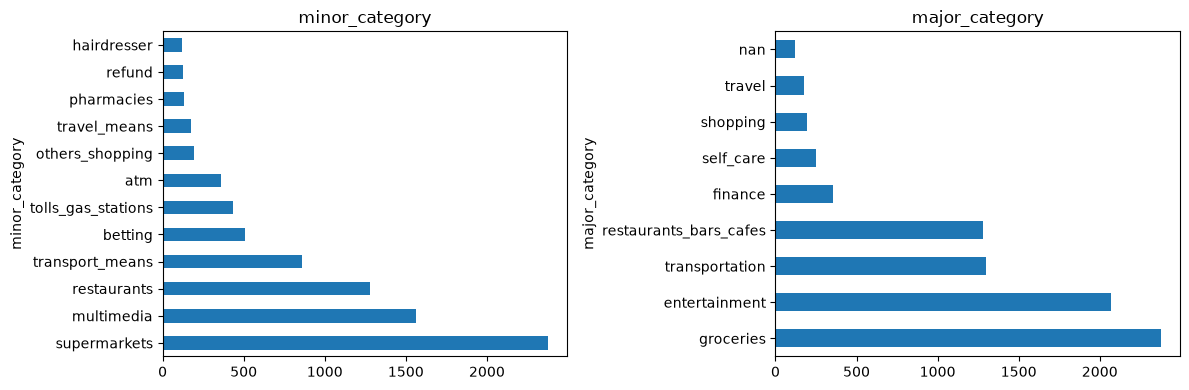

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['minor_category'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('minor_category')
df['major_category'].value_counts(dropna=False).plot(kind='barh', ax=axes[1])
axes[1].set_title('major_category')
plt.tight_layout()
plt.show()

Classes déséquilibrées : j'en tiens compte avec `class_weight` et en évaluant en macro-F1.

### Correspondance minor -> major

In [7]:
check = df.dropna(subset=['major_category']).groupby('minor_category')['major_category'].nunique()
print('chaque minor a un seul major :', (check == 1).all())
mapping = (df.dropna(subset=['major_category'])
             .groupby('minor_category')['major_category']
             .agg(lambda s: s.mode().iat[0]))
MINOR_TO_MAJOR = mapping.to_dict()
MINOR_TO_MAJOR['refund'] = None
MINOR_TO_MAJOR

chaque minor a un seul major : True


{'atm': 'finance',
 'betting': 'entertainment',
 'hairdresser': 'self_care',
 'multimedia': 'entertainment',
 'others_shopping': 'shopping',
 'pharmacies': 'self_care',
 'restaurants': 'restaurants_bars_cafes',
 'supermarkets': 'groceries',
 'tolls_gas_stations': 'transportation',
 'transport_means': 'transportation',
 'travel_means': 'travel',
 'refund': None}

## Nettoyage du texte
Les descripteurs portent du bruit, notamment des préfixes de processeurs de paiement (`PAYPAL *`, `SQ *`...) qui masquent le vrai marchand. Je les retire avant de vectoriser.

In [8]:
def clean_text(x):
    x = str(x).lower()
    x = re.sub(r'\b(paypal|sq|sumup|ztl|zettle|stripe)\s*\*', ' ', x)
    x = re.sub(r'[^a-z\s]', ' ', x)
    return re.sub(r'\s+', ' ', x).strip()

clean_text('PAYPAL *UBER BV')

'uber bv'

## Features
Le nom nettoyé plus quelques signaux numériques (remboursement), et un drapeau `amount_isnan`.

In [9]:
def make_features(d):
    d = d.copy()
    d['clean_title'] = d['title'].fillna('').map(clean_text)
    amt_raw = pd.to_numeric(d['amount_value'], errors='coerce')
    d['amount_isnan'] = amt_raw.isna().astype(int)
    amt = amt_raw.fillna(0)
    d['is_credit'] = (amt > 0).astype(int)
    status = d['status'] if 'status' in d else pd.Series(['completed'] * len(d))
    d['is_refunded'] = (status.astype(str) == 'refunded').astype(int)
    d['log_amount'] = np.log1p(amt.abs())
    return d

df = make_features(df)
df[['clean_title', 'is_credit', 'is_refunded', 'log_amount', 'amount_isnan']].head()

,clean_title,is_credit,is_refunded,log_amount,amount_isnan
0,mac donald s,0,0,3.143290,0
1,carrefourmarket,0,0,2.057963,0
2,total,0,0,3.993787,0
3,proxi,0,0,2.029463,0
4,betclic,0,0,4.234686,0


## Le modèle
TF-IDF **caractère** (`char_wb` 3-5, robuste aux noms collés/tronqués) -> SVD pour densifier -> RandomForest. Je borne `max_depth=16` : ça limite le surapprentissage et garde l'artefact léger (~28 Mo, committable).

In [10]:
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2, analyzer='char_wb', ngram_range=(3, 5))),
    ('svd', TruncatedSVD(n_components=200, random_state=42)),
])
num_cols = ['is_credit', 'is_refunded', 'log_amount', 'amount_isnan']
pre = ColumnTransformer([
    ('text', text_pipe, 'clean_title'),
    ('num', 'passthrough', num_cols),
])
model = Pipeline([
    ('pre', pre),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=16,
                                  class_weight='balanced_subsample',
                                  random_state=42, n_jobs=-1)),
])

## Évaluation
Split temporel : apprentissage sur les 80 % de transactions les plus anciennes, test sur les 20 % les plus récentes.

In [11]:
d = df.sort_values('created_at').reset_index(drop=True)
y = d['minor_category']
cut = int(len(d) * 0.8)
model.fit(d.iloc[:cut], y.iloc[:cut])
pred = model.predict(d.iloc[cut:])
print('accuracy :', round(accuracy_score(y.iloc[cut:], pred), 3))
print('macro-F1 :', round(f1_score(y.iloc[cut:], pred, average='macro'), 3))

accuracy : 0.934
macro-F1 : 0.906


In [12]:
print(classification_report(y.iloc[cut:], pred, zero_division=0))

                    precision    recall  f1-score   support

               atm       0.94      0.97      0.96        77
           betting       0.95      0.88      0.91        88
       hairdresser       0.93      1.00      0.96        26
        multimedia       0.96      0.97      0.97       309
   others_shopping       0.56      0.62      0.59        29
        pharmacies       0.93      0.96      0.94        26
            refund       1.00      0.93      0.96        27
       restaurants       0.90      0.93      0.91       258
      supermarkets       0.95      0.95      0.95       498
tolls_gas_stations       0.94      0.92      0.93        83
   transport_means       0.95      0.89      0.92       174
      travel_means       0.93      0.83      0.88        30

          accuracy                           0.93      1625
         macro avg       0.91      0.90      0.91      1625
      weighted avg       0.93      0.93      0.93      1625



Macro-F1 plus parlante que l'accuracy vu le déséquilibre. Les classes sans marchand récurrent (others_shopping) restent les plus faibles.

In [13]:
pd.crosstab(y.iloc[cut:], pred, normalize='index').round(2)

col_0,atm,betting,hairdresser,multimedia,others_shopping,pharmacies,refund,restaurants,supermarkets,tolls_gas_stations,transport_means,travel_means
minor_category,,,,,,,,,,,,
atm,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00
betting,0.00,0.88,0.00,0.09,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00
hairdresser,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
multimedia,0.00,0.01,0.00,0.97,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
others_shopping,0.00,0.00,0.00,0.17,0.62,0.00,0.00,0.00,0.21,0.00,0.00,0.00
pharmacies,0.00,0.00,0.00,0.00,0.00,0.96,0.00,0.04,0.00,0.00,0.00,0.00
refund,0.00,0.00,0.04,0.00,0.00,0.04,0.93,0.00,0.00,0.00,0.00,0.00
restaurants,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.93,0.05,0.00,0.02,0.00
supermarkets,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.02,0.95,0.01,0.00,0.00


## Modèle final et sauvegarde
Je réentraîne sur toutes les données et je sauvegarde le modèle **et** la table `minor -> major` dans `model.joblib`. C'est ce fichier que l'API charge.

In [14]:
final_model = model.fit(d, y)
joblib.dump({'model': final_model, 'minor_to_major': MINOR_TO_MAJOR}, 'model.joblib')
print('modele sauvegarde dans model.joblib')

modele sauvegarde dans model.joblib


## Prédire une transaction
Même logique que dans `app.py`.

In [15]:
def predict_one(txn):
    row = make_features(pd.DataFrame([txn]))
    minor = final_model.predict(row)[0]
    proba = float(final_model.predict_proba(row)[0].max())
    return {'minor_category': minor,
            'major_category': MINOR_TO_MAJOR.get(minor),
            'confidence': round(proba, 3)}

for t in [
    {'title': 'CARREFOURMARKET', 'amount_value': -12.5},
    {'title': 'BETCLIC', 'amount_value': -50},
    {'title': 'RETRAIT DAB', 'amount_value': -50},
    {'title': 'REMBOURSEMENT', 'amount_value': 29.9, 'status': 'refunded'},
    {'title': 'UN MARCHAND INCONNU XYZ', 'amount_value': -9.9},
]:
    print(t['title'], '->', predict_one(t))

CARREFOURMARKET -> {'minor_category': 'supermarkets', 'major_category': 'groceries', 'confidence': 0.836}
BETCLIC -> {'minor_category': 'betting', 'major_category': 'entertainment', 'confidence': 0.995}
RETRAIT DAB -> {'minor_category': 'atm', 'major_category': 'finance', 'confidence': 0.999}
REMBOURSEMENT -> {'minor_category': 'refund', 'major_category': None, 'confidence': 0.78}
UN MARCHAND INCONNU XYZ -> {'minor_category': 'supermarkets', 'major_category': 'groceries', 'confidence': 0.368}


## L'API
Le service est dans `app.py`. Il **charge** `model.joblib` (créé ci-dessus) et expose `POST /predict`. Si le fichier est absent, il réentraîne automatiquement.

```bash
uvicorn app:app --port 8000
# puis ouvrir http://127.0.0.1:8000/docs
```

## Si j'avais eu plus de temps

- Comparer à un baseline plus simple (régression logistique sur TF-IDF) pour isoler l'apport de la SVD et du RandomForest.
- Évaluer aussi sur un split par marchand (`GroupShuffleSplit`) pour mesurer la généralisation aux marchands inconnus, pas seulement dans le temps.
- **Enrichir les marchands inconnus via une API externe** : pour un marchand jamais vu, le nom seul ne suffit pas. Je récupérerais une courte description du marchand via une API de recherche (Tavily / Google Places, ou le répertoire SIRENE pour l'activité), puis je calculerais un **embedding** de cette description (via une API d'embeddings) que j'ajouterais comme feature. Ça attaque la longue traîne de marchands inconnus, là où le TF-IDF sur le nom plafonne.
- Traiter les cas particuliers par des règles : `refund` via le `status`, l'ATM via une liste de banques / mots-clés.
- En production, utiliser le code MCC de la transaction (catégorie marchand standard de l'industrie), absent de ce jeu synthétique mais le signal le plus fiable. Côté texte, un `HashingVectorizer` (sans vocabulaire à persister) simplifierait le service à grande échelle.
- Renvoyer une catégorie `incertain` sous un seuil de confiance, pour qu'une appli PFM demande confirmation à l'utilisateur au lieu de mal classer.